In [4]:
import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import random
from itertools import combinations, chain
import functools
from typing import Callable
import math
import galois
from tqdm import tqdm

In [5]:
# Basic parameters for the experiment
SHARE_NUMBER = N = 10
MINIMUM_SHARE = K = 3
BITLENGTH = M = 8
ALPHA = ...
R = (..., ...) # sould be symmetrical in case of experiment, but we also have asymmetrical cases (ref paper).

In [6]:
# Preparing types for data

# a 1D array of bits with shape size of M
Share = npt.NDArray[np.bool_] 
# a 2D array of bits with shape size of N x M
C_Matrix = npt.NDArray[np.bool_]

In [7]:
def display(share: Share | C_Matrix, fmt: tuple[int, int] = (1, -1), Label: str = "", grid=False) -> None:
    """Display a single share as an image."""
    fig, ax = plt.subplots()
    # check if the share can be reshaped to the specified format
    if share.size != np.prod(fmt) and fmt != (1, -1):
        raise ValueError(f"Cannot reshape share of size {share.size} to format {fmt}.")
    
    # quick way to reshape the share if it's 1D, otherwise keep it as is
    match share.ndim:
        case 1: 
            share_reshaped = share.reshape(fmt)  
        case 2: 
            share_reshaped = share
        case _: 
            raise ValueError(f"Unsupported share dimensions: {share.ndim})")
    assert share_reshaped.ndim == 2, "Share must be 2D after reshaping."

    h, w = share_reshaped.shape
    ax.imshow(
        share_reshaped,
        cmap="gray_r",
        vmin=0,
        vmax=1
    )

    # Explicit separators on top of the image to avoid backend/style grid quirks
    if grid:
        for x in range(w + 1):
            ax.axvline(x - 0.5, color="lightgray", linewidth=1)
        for y in range(h + 1):
            ax.axhline(y - 0.5, color="lightgray", linewidth=1)

    ax.set_xlim(-0.5, w - 0.5)
    ax.set_ylim(h - 0.5, -0.5)
    ax.set_title(Label)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    plt.show()

In [8]:
def shuffle(matrix: C_Matrix)-> None:
    """Shuffle the column of a matrix."""
    np.random.shuffle(matrix.T)
    matrix.T


def random_sampling_shares(C_0: C_Matrix, C_1: C_Matrix, secret_pixel: bool|None=None) ->tuple[bool, list[Share]]:
    """
    TODO validate that this process is as described in the paper.
    Emulate a Random share creation based on the two matrix S_0 and S_1 sampled from C_0 and C_1.
    based on a secrete pixel 
    
    output 
    - list share: the generated share as a 1D array of bits (size M) 
    """
    
    if C_0.shape != C_1.shape:
        raise ValueError(f"C_0 and C_1 must have the same shape, got {C_0.shape} and {C_1.shape}.")
    N, _ = C_0.shape
    
    secret_pixel_value = secret_pixel if secret_pixel is not None else np.random.choice([False, True])
    C = C_1 if secret_pixel_value else C_0

    # implementation column permutation
    col_order = np.random.permutation(C.shape[1])
    C_permuted = np.zeros_like(C)

    for new_pos, old_pos in enumerate(col_order):
        C_permuted[:, new_pos] = C[:, old_pos]
        
    C = C_permuted

    shares = []
    for i in range(N):
        share = C[i]
        shares.append(share)
    return secret_pixel_value, shares
    

Test matrix of shares:
[ True False False  True  True False False False]


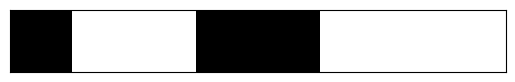

Test matrix 2 of shares:
[False False  True  True  True False False False]


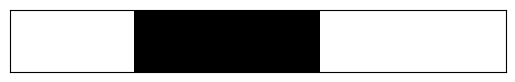

Result of share addition:
[ True False  True  True  True False False False]


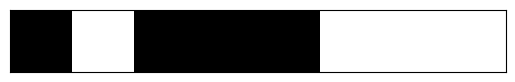

In [9]:
def share_add(a_share: Share, b_share: Share) -> Share:
    assert a_share.shape == b_share.shape, "Shares must have the same shape for addition."
    return np.logical_or(a_share, b_share)

def matrix_share_add(matrix_share: C_Matrix) -> Share:
    assert matrix_share.ndim == 2, "Input must be a 2D matrix of shares."
    return np.logical_or.reduce(matrix_share, axis=0)

SHARE_SIZE = (BITLENGTH,)
test_matrix = np.random.randint(0, 2, size=SHARE_SIZE).astype(bool)
test_m2 = np.random.randint(0, 2, size=SHARE_SIZE).astype(bool)
print("Test matrix of shares:")
print(test_matrix)
display(test_matrix)
print("Test matrix 2 of shares:")
print(test_m2)
display(test_m2)
result = share_add(test_matrix, test_m2)
print("Result of share addition:")
print(result)
display(result)

# First impl, 3 out of 3 shares
- size of shares: 4 bits
- number of shares: 3
- C=(3, 4)

Thus:

- $C_{0}$ is a column of 0s concatenated with negated identity matrix.
- $C_{1}$ is the negated version of C_0.

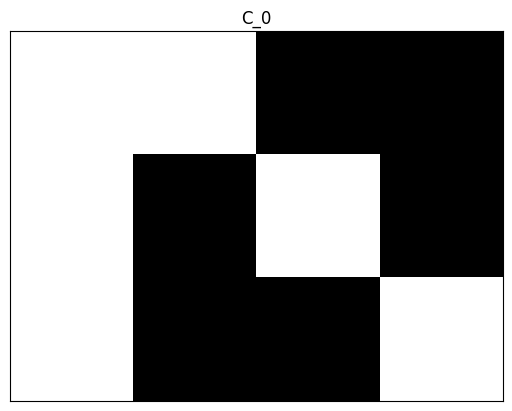

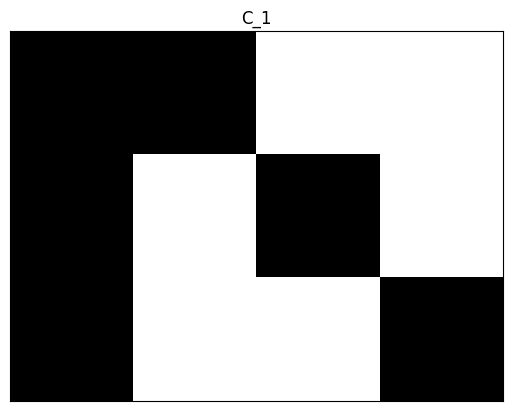

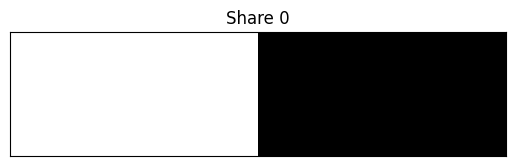

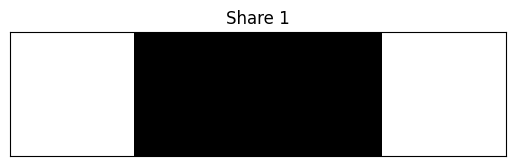

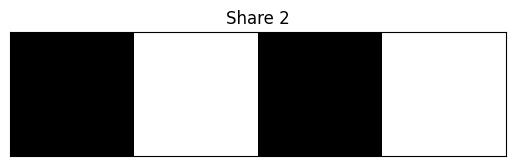

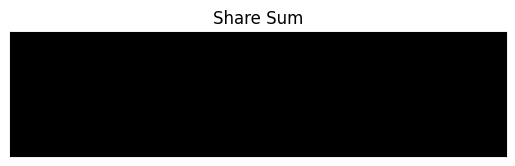

Average of share sum: 1.0
The secret should be True. (black, 1) 
Secret pixel value: True


In [10]:
N = 3
C_1 = np.hstack((np.ones((N, 1), dtype=bool), np.eye(N, dtype=bool)))
J_0 = ~C_1

display(J_0, Label="C_0")
display(C_1, Label="C_1")

shuffle(J_0)
shuffle(C_1)

secret, shares = random_sampling_shares(J_0, C_1)
for i, share in enumerate(shares):
    display(share, Label=f"Share {i}")
share_sum = matrix_share_add(np.array(shares))
display(share_sum, Label="Share Sum")
avg = np.average(share_sum)
print(f"Average of share sum: {avg}")
if avg == 0.75:
    print("The secret should be False. (white, 0) ")
elif avg == 1.0:
    print("The secret should be True. (black, 1) ")
print (f"Secret pixel value: {secret}")
    



# General K out of K scheme
- size of $k\times 2^{k-1}$

K out of K scheme 2:

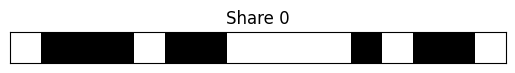

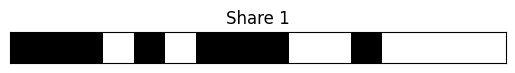

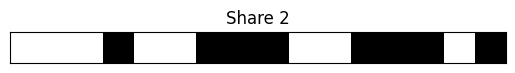

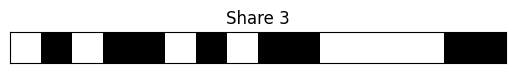

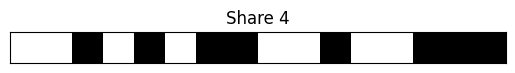

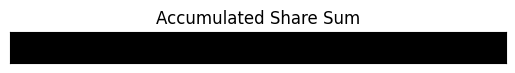

True is the secret pixel value.


In [24]:
K = 5
def powerset_even_odd(s: set) -> tuple[set, set]:
    """Generate the powerset of a given set."""
    all_subsets = set(chain.from_iterable(combinations(s, r) for r in range(len(s) + 1))) # see docs from itertools
    even_subsets = {subset for subset in all_subsets if len(subset) % 2 == 0}
    odd_subsets = all_subsets - even_subsets
    return even_subsets, odd_subsets

def generate_kok_matrices2(K: int) -> tuple[C_Matrix, C_Matrix]:
    
    S_0 = np.zeros((K,2**(K-1)), dtype=bool)
    S_1 = np.zeros((K,2**(K-1)), dtype=bool)
    
    W = set(range(K))
    PI, Sigma = powerset_even_odd(W)
    
    PI = list(PI)
    Sigma = list(Sigma)
    
    #sanity check 
    if len(PI) != 2**(K-1) or len(Sigma) != 2**(K-1):
        raise ValueError(f"Expected 2^(K-1) subsets in both PI and Sigma, got {len(PI)} and {len(Sigma)}.")
    
    
    for i in W: # e_i or each element of W
        for j in range(2**(K-1)):
            if i in PI[j]:
                S_0[i, j] = True
            if i in Sigma[j]:
                S_1[i, j] = True
    return S_0, S_1

secret, vals = random_sampling_shares(*generate_kok_matrices2(K))
for i, share in enumerate(vals):
    display(share, Label=f"Share {i}")


sum_share = functools.reduce(share_add, vals)
display(sum_share, Label="Accumulated Share Sum")
print(secret, "is the secret pixel value.")

# K out of N scheme:

## Hash family construction:
testing if the hash family construction is correct 
using a simple Monte Carlo approach.

In [12]:
def hash_family_construction(N: int, K: int, L: int|None = None) -> Callable:
    # primality check can skip if we use a idependent prime number generator, but from the paper it seems they just want to use K as the prime number for the field, so we can just check if K is prime.
    if K < 2:
        raise ValueError(f"k must be a prime number greater than 1, but got {K}.")
    i=1
    while (i:= i+1)**2 <= K:
        if K % i == 0:
            raise ValueError(f"k must be a prime number, but {K} is divisible by {i}.")
    
    
    # this is derive from formula of k**l >= n or traditionaly if P >= n 
    if L is None:
        L = math.ceil(math.log(N, K))
    elif K**L < N:
        raise ValueError(f"Invalid parameters: k^l must be >= n, but got k={K}, l={L}, and n={N}. either leave l as Default or increase l.")
    
    GF = galois.GF(K**L)
    coef = GF.Random(K)
    q = galois.Poly(coef, field=GF) # create a random polynomial of degree at most k-1 over the field GF(k^l)
    def h(x):
        return int(q(GF(x))) % K # equation -> h(x) = q(x) mod k, where q is a random polynomial of degree at most k-1 over the field GF(k^l) 
    h.poly = q # this was AI guided debugging.
    return h
    # alternative implementation without galois library, but was flagged as incorrect by AI 
    # reason -> simple modulo operation not being a field operation but more of a ring operation, so we will stick to the galois library implementation for correctness.
    # using numpy polyval(coeffs, x) to evaluate the polynomial at a given point x
    # GF_SIZE = K**L
    # coeffs = np.random.randint(0, high=GF_SIZE-1, size=(K,), dtype=int)
    # q_x = lambda x: np.polyval(coeffs, x) % GF_SIZE  # noqa: E731
    # h_x = lambda x: q_x(x) % K # noqa: E731
    # return h_x

100%|██████████| 10000/10000 [00:02<00:00, 4039.01it/s]


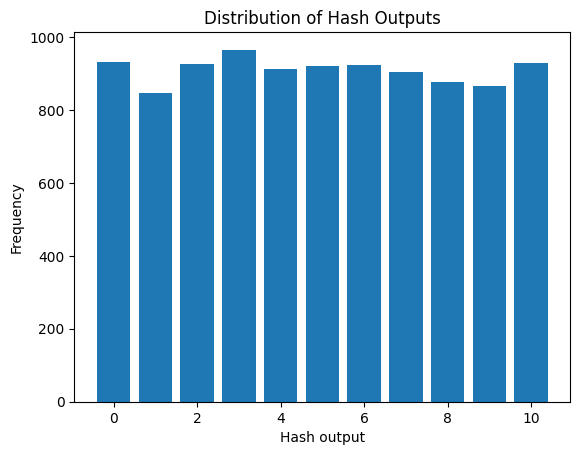

Estimating collision probability: 100%|██████████| 10000/10000 [00:04<00:00, 2023.76it/s]

Keys: x1=8, x2=20
Empirical collision prob : 0.0935
Theoretical bound (1/k)  : 0.0909


In [14]:
trial = 10_000
dic = dict()
k = 11
n = 25
for i in tqdm(range(trial)):
    h = hash_family_construction(N=n, K=k)
    test = h(random.randint(0, n ))
    dic[test] = dic.get(test, 0) + 1
plt.bar(dic.keys(), dic.values())
plt.xlabel("Hash output")
plt.ylabel("Frequency")
plt.title("Distribution of Hash Outputs")
plt.show()

x1, x2 = random.randint(0, n), random.randint(0, n)
collisions = sum(
    hash_family_construction(n, k)(x1) == hash_family_construction(n, k)(x2)
    for _ in tqdm(range(trial), desc="Estimating collision probability")
)
    
empirical = collisions / trial
theoretical_bound = 1 / k

print(f"Keys: x1={x1}, x2={x2}")
print(f"Empirical collision prob : {empirical:.4f}")
print(f"Theoretical bound (1/k)  : {theoretical_bound:.4f}")

## Core functions for the K out of N scheme

In [28]:
def T_matrices(k:int, r:int) -> tuple[list[C_Matrix], list[C_Matrix]]:
    #TODO: double check where m is used in the construction
    
    #note that if the number of permutations of 2**(k-1) columns is less than r, we will not be able to generate r unique matrices, so we need to check that first.
    #sanity check
    if math.factorial(2**(k-1)) < r:
        raise ValueError(f"Cannot generate {r} unique matrices from permutations of 2^(k-1) columns, as there are only {math.factorial(2**(k-1))} unique permutations.")
    
    C_0_set = []
    C_1_set = []
    
    kok_S_0, kok_S_1 = generate_kok_matrices2(k)
    
    mat_in = lambda mat, list_of_matrices: np.any(map(lambda x: np.array_equal(mat, x), list_of_matrices))
    
    while len(C_0_set) < r or len(C_1_set) < r:
        if len(C_0_set) < r and mat_in(kok_S_0, C_0_set): # if the matrix is not already in the set, we can add it to the set until we have r unique matrices in each set.
            C_0_set.append(kok_S_0.copy()) # use copy to avoid reference issue when shuffling
            shuffle(kok_S_0)
        if len(C_1_set) < r and mat_in(kok_S_1, C_1_set):
            C_1_set.append(kok_S_1.copy())
            shuffle(kok_S_1)
    for cO in C_0_set:
        display(cO, Label="C_0 matrix")
    for c1 in C_1_set:
        display(c1, Label="C_1 matrix")
    return C_0_set, C_1_set


def upscale_kok_to_kon(kok_S: C_Matrix,h: Callable, n: int) -> C_Matrix:
    """
    Upscale a K out of K matrix to a K out of N matrix using the hash function h.
    from a matrix of size (k, 2^(k-1)) to a matrix of size (n, 2^(k-1)) by using the hash function h  
    """
    _, m = kok_S.shape
    kon_S = np.zeros((n, m), dtype=bool) # should be a n*2^(k-1) matrix
    for i in range(n):
        hi = h(i)
        kon_S[i] = kok_S[hi]
    return kon_S

def generate_kon_matrices(n:int ,k: int, r:int , _alpha: float) -> tuple[C_Matrix, C_Matrix]:
    """Generate the C_0 and C_1 matrices for the K out of N scheme."""
    kok_C_0_set, kok_C_1_set = T_matrices(k, r)
    _, m = kok_C_0_set[0].shape
        
    l = math.ceil(math.log(n, k))
    kon_S0 = np.zeros((n, m*l), dtype=bool)
    kon_S1 = np.zeros((n, m*l), dtype=bool)
    for l_idx in range(l):
        hash_func = hash_family_construction(N=n, K=k, L=l) # generate a new hash function for each submatrix to ensure independence
        sub_kon_S0 = upscale_kok_to_kon(kok_C_0_set[l_idx], hash_func, n)
        sub_kon_S1 = upscale_kok_to_kon(kok_C_1_set[l_idx], hash_func, n)
        # print(f"Submatrix {l_idx} for C_0:")
        # display(sub_kon_S0, Label=f"Submatrix {l_idx} for C_0")
        kon_S0[:, l_idx*m:(l_idx+1)*m] = sub_kon_S0
        kon_S1[:, l_idx*m:(l_idx+1)*m] = sub_kon_S1
    return kon_S0, kon_S1

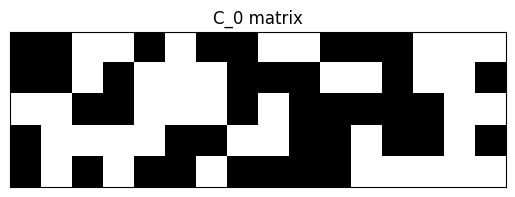

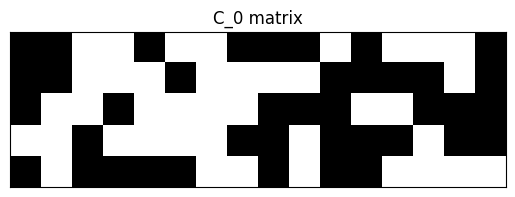

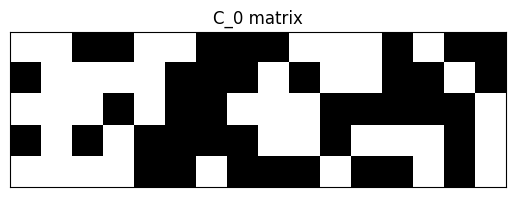

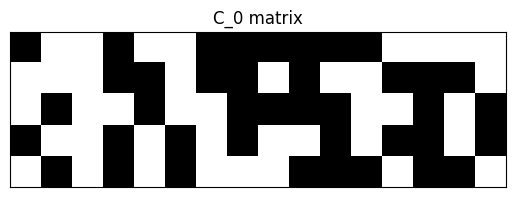

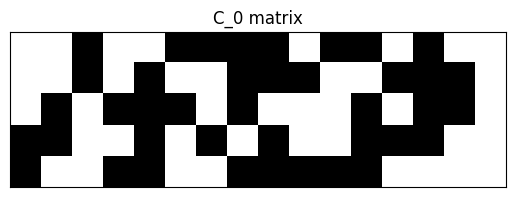

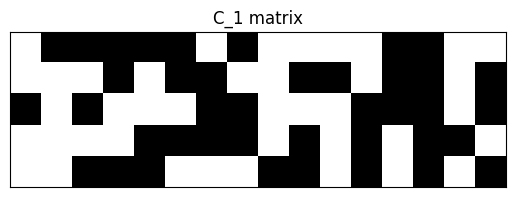

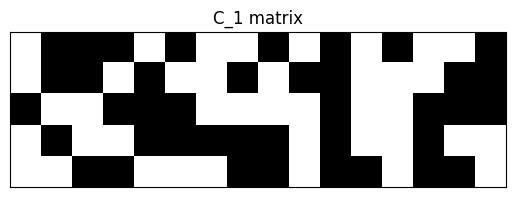

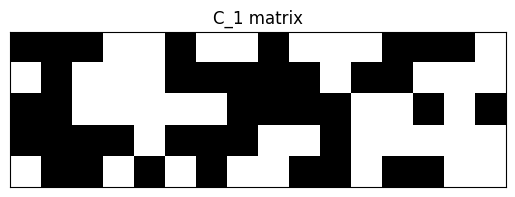

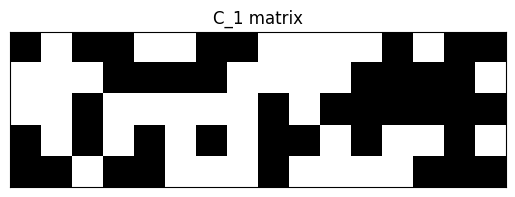

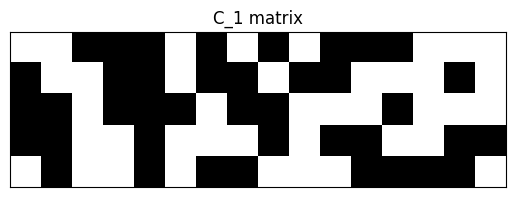

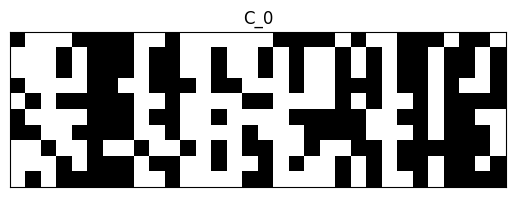

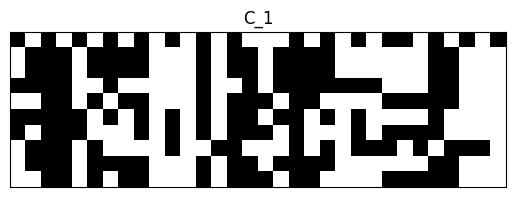

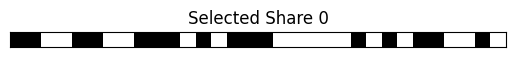

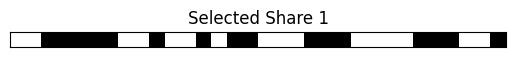

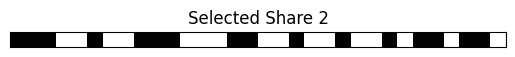

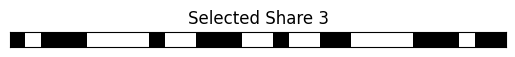

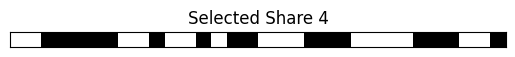

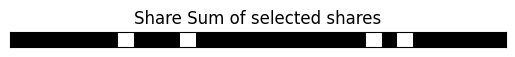

Average of share sum: 0.875
Secret pixel value: False


In [29]:
N = 10
K = 5
S0, S1 = generate_kon_matrices(n=N, k=K, r=5, _alpha=10)
shuffle(S0)
shuffle(S1)
display(S0, Label="C_0")
display(S1, Label="C_1")
secret , shares = random_sampling_shares(S0, S1)

# get k random shares and check if we can recover the secret
selected_shares = random.choices(shares, k=K)
for i, share in enumerate(selected_shares):
    display(share, Label=f"Selected Share {i}")
share_sum = functools.reduce(share_add, selected_shares)
display(share_sum, Label="Share Sum of selected shares")
avg = np.average(share_sum)
print(f"Average of share sum: {avg}")
print (f"Secret pixel value: {secret}")